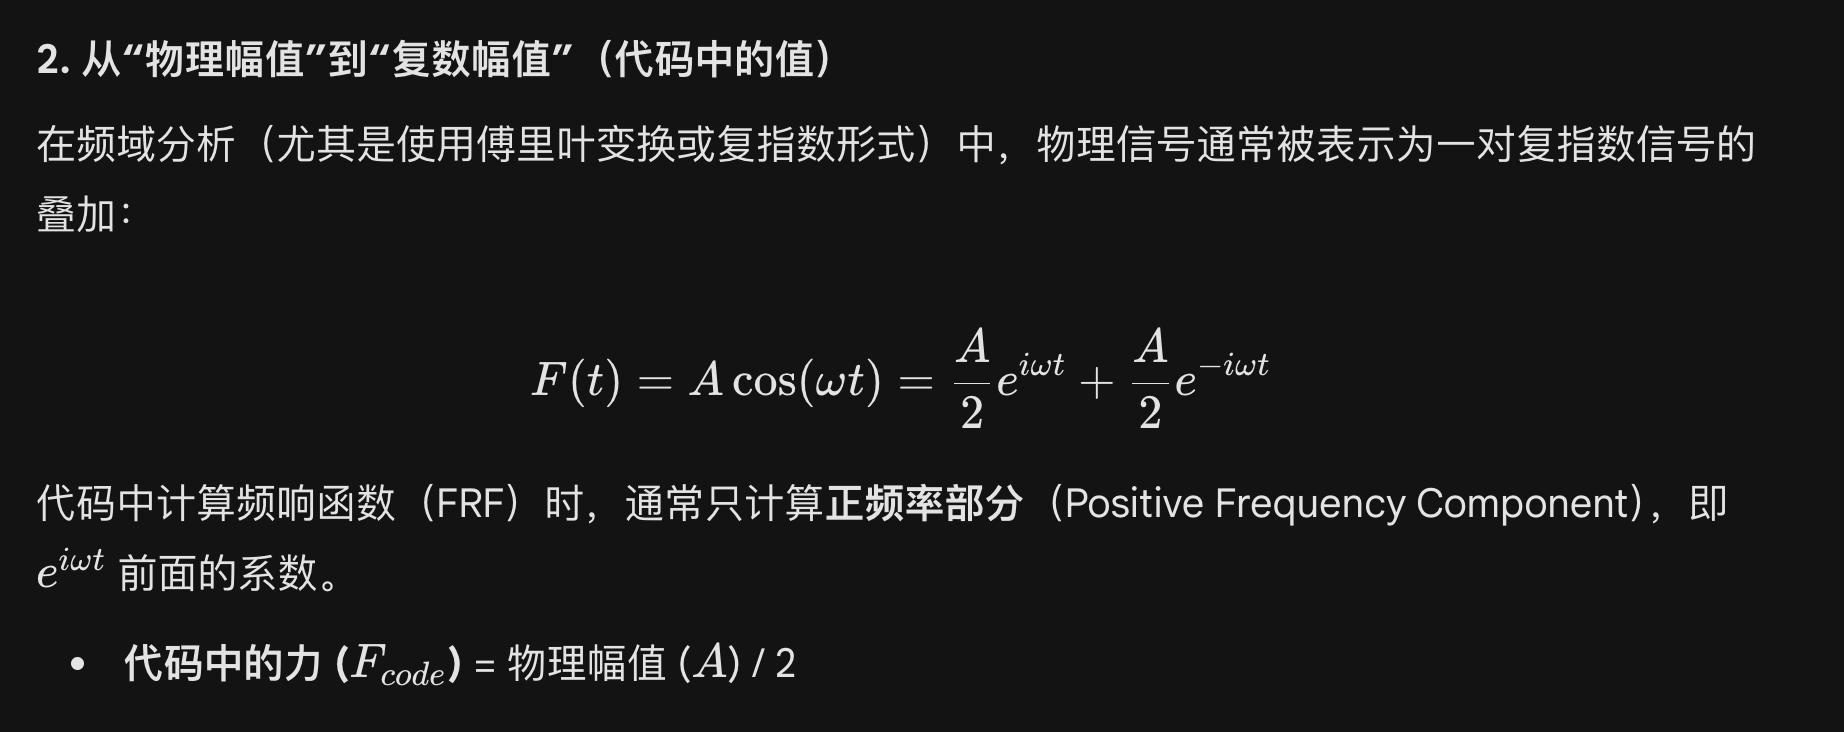

矩阵数据读取成功。

--- 固有频率 (Natural Frequencies) ---
Mode 1: 0.4002 Hz (2.5146 rad/s)
Mode 2: 1.3050 Hz (8.1995 rad/s)
Mode 3: 3.0227 Hz (18.9923 rad/s)
Mode 4: 4.3208 Hz (27.1486 rad/s)
Mode 5: 14.2233 Hz (89.3675 rad/s)
Mode 6: 14.8241 Hz (93.1428 rad/s)
Mode 7: 19.8618 Hz (124.7951 rad/s)
Mode 8: 36.9905 Hz (232.4179 rad/s)


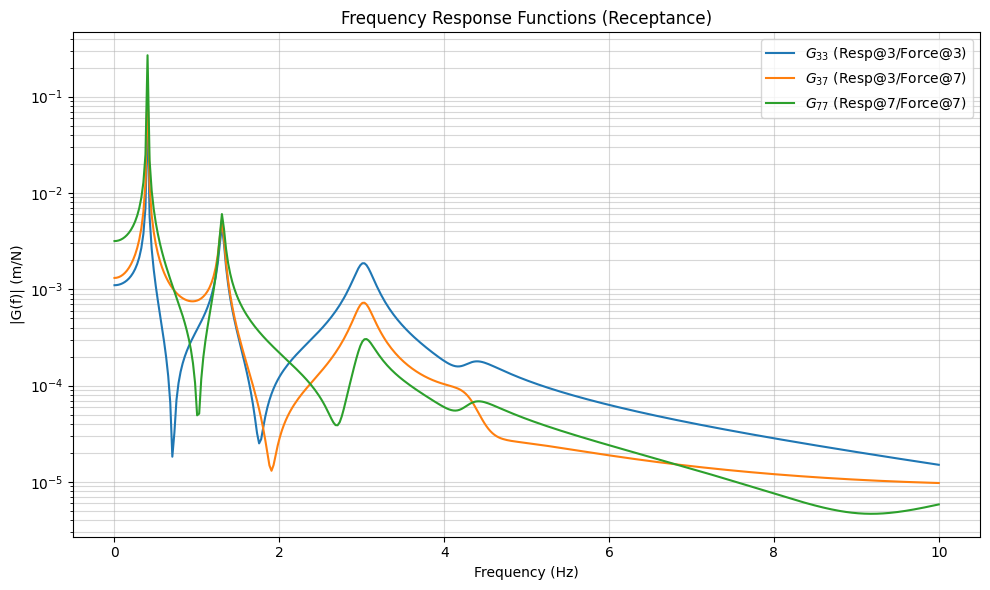


--- 稳态响应计算 (Steady State Response) ---

[Case 1 (1.0 Hz)]
  Excitation: 2.0 N at DOF 7, Freq = 1.0 Hz
  Response at DOF 3:
    Magnitude:    1.5258 mm
    Phase:        178.0851 deg
    Peak-to-Peak: 6.1033 mm (Logic: 4 * Amp)

[Case 2 (2.85 Hz)]
  Excitation: 4.0 N at DOF 3, Freq = 2.85 Hz
  Response at DOF 3:
    Magnitude:    4.1775 mm
    Phase:        -34.1212 deg
    Peak-to-Peak: 16.7100 mm (Logic: 4 * Amp)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, eig, norm

# ==========================================
#               用户配置区域
#           (在这里修改你的条件)
# ==========================================

# 1. 文件路径配置
STIFFNESS_FILE = 'stiffness_matrix.xlsx'
MASS_FILE = 'mass_matrix.xlsx'
DAMPING_FILE = 'damping_matrix.xlsx'

# 2. 频率分析范围
FREQ_START = 0.0   # Hz
FREQ_END   = 10.0  # Hz
FREQ_POINTS = 400  # 计算点数

# 3. 绘图关注的频响函数 (输入真实自由度编号，如 3 代表 DOF 3)
# 格式: (激励自由度, 响应自由度)
FRF_TO_PLOT = [
    (3, 3),  # G33: Force at 3, Response at 3
    (7, 3),  # G37: Force at 7, Response at 3 
    (7, 7)   # G77: Force at 7, Response at 7
]

# 4. 特定工况计算 (稳态响应)
# 每个字典代表一个工况
LOAD_CASES = [
    {
        'name': 'Case 1 (1.0 Hz)',
        'freq_hz': 1.0,           # 激励频率 (Hz)
        'force_dof': 7,           # 施力自由度
        'force_mag': 2.0,         # 力的大小 (N) (注意代码逻辑中可能是复振幅)
        'resp_dof': 3             # 观察响应的自由度
    },
    {
        'name': 'Case 2 (2.85 Hz)',
        'freq_hz': 2.85,
        'force_dof': 3,
        'force_mag': 4.0,
        'resp_dof': 3
    }
]

# ==========================================
#             核心逻辑代码 (无需修改)
# ==========================================

def load_data():
    """读取Excel数据，如果文件不存在则报错"""
    try:
        K = pd.read_excel(STIFFNESS_FILE).values
        M = pd.read_excel(MASS_FILE).values
        C = pd.read_excel(DAMPING_FILE).values
        print("矩阵数据读取成功。")
        return K, M, C
    except FileNotFoundError as e:
        print(f"错误: 找不到文件 {e.filename}。请确保Excel文件在同一目录下。")
        # 为了演示，如果找不到文件，可以生成随机矩阵 (仅用于测试代码运行)
        # print("生成随机矩阵用于测试...")
        # size = 8
        # return np.eye(size)*1000, np.eye(size)*10, np.eye(size)*1
        raise e

def analyze_system():
    # 1. 加载数据
    K, M, C = load_data()
    dof = K.shape[0]

    # 2. 模态分析 (固有频率)
    # 求解 A = M^-1 * K
    A = inv(M) @ K
    vals, vecs = eig(A)
    omega_n = np.sqrt(np.abs(vals)) # 固有圆频率
    
    # 排序
    idx = omega_n.argsort()
    omega_n = omega_n[idx]
    f_n = omega_n / (2 * np.pi) # 固有频率 (Hz)

    print("\n--- 固有频率 (Natural Frequencies) ---")
    for i, f in enumerate(f_n):
        print(f"Mode {i+1}: {f:.4f} Hz ({omega_n[i]:.4f} rad/s)")

    # 3. 频响函数计算 (FRF)
    f_range = np.linspace(FREQ_START, FREQ_END, FREQ_POINTS)
    w_range = 2 * np.pi * f_range
    G_stack = []

    for w in w_range:
        # 动刚度 Z = K - w^2 M + i w C
        Z = K - (w**2)*M + 1j*w*C
        G_stack.append(inv(Z))
    
    G_stack = np.array(G_stack) # Shape: (Points, DOF, DOF)

    # 4. 绘图
    plt.figure(figsize=(10, 6))
    for (force_idx, resp_idx) in FRF_TO_PLOT:
        # 转换为 0-based 索引
        f_i = force_idx - 1
        r_i = resp_idx - 1
        
        # 提取幅值
        mag = np.abs(G_stack[:, r_i, f_i])
        plt.semilogy(f_range, mag, label=f'$G_{{{resp_idx}{force_idx}}}$ (Resp@{resp_idx}/Force@{force_idx})')

    plt.title("Frequency Response Functions (Receptance)")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("|G(f)| (m/N)")
    plt.grid(True, which="both", alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 5. 特定工况计算
    print("\n--- 稳态响应计算 (Steady State Response) ---")
    for case in LOAD_CASES:
        f_hz = case['freq_hz']
        w = 2 * np.pi * f_hz
        
        # 构建力向量
        F_vec = np.zeros(dof)
        force_node_idx = case['force_dof'] - 1
        F_vec[force_node_idx] = case['force_mag']
        
        # 计算响应
        Z = K - (w**2)*M + 1j*w*C
        G = inv(Z)
        X_vec = G @ F_vec
        
        # 提取目标自由度响应
        resp_node_idx = case['resp_dof'] - 1
        X_target = X_vec[resp_node_idx]
        
        # 计算指标
        amp_mm = np.abs(X_target) * 1000
        phase_deg = np.rad2deg(np.angle(X_target))
        # 保持原代码的逻辑: Peak-to-Peak = 4 * abs(X)
        pk_pk_mm = 4 * np.abs(X_target) * 1000 
        
        print(f"\n[{case['name']}]")
        print(f"  Excitation: {case['force_mag']} N at DOF {case['force_dof']}, Freq = {f_hz} Hz")
        print(f"  Response at DOF {case['resp_dof']}:")
        print(f"    Magnitude:    {amp_mm:.4f} mm")
        print(f"    Phase:        {phase_deg:.4f} deg")
        print(f"    Peak-to-Peak: {pk_pk_mm:.4f} mm (Logic: 4 * Amp)")

if __name__ == "__main__":
    analyze_system()

Matrix data loaded successfully.
Calculating Frequency Response for Force at DOF 1...


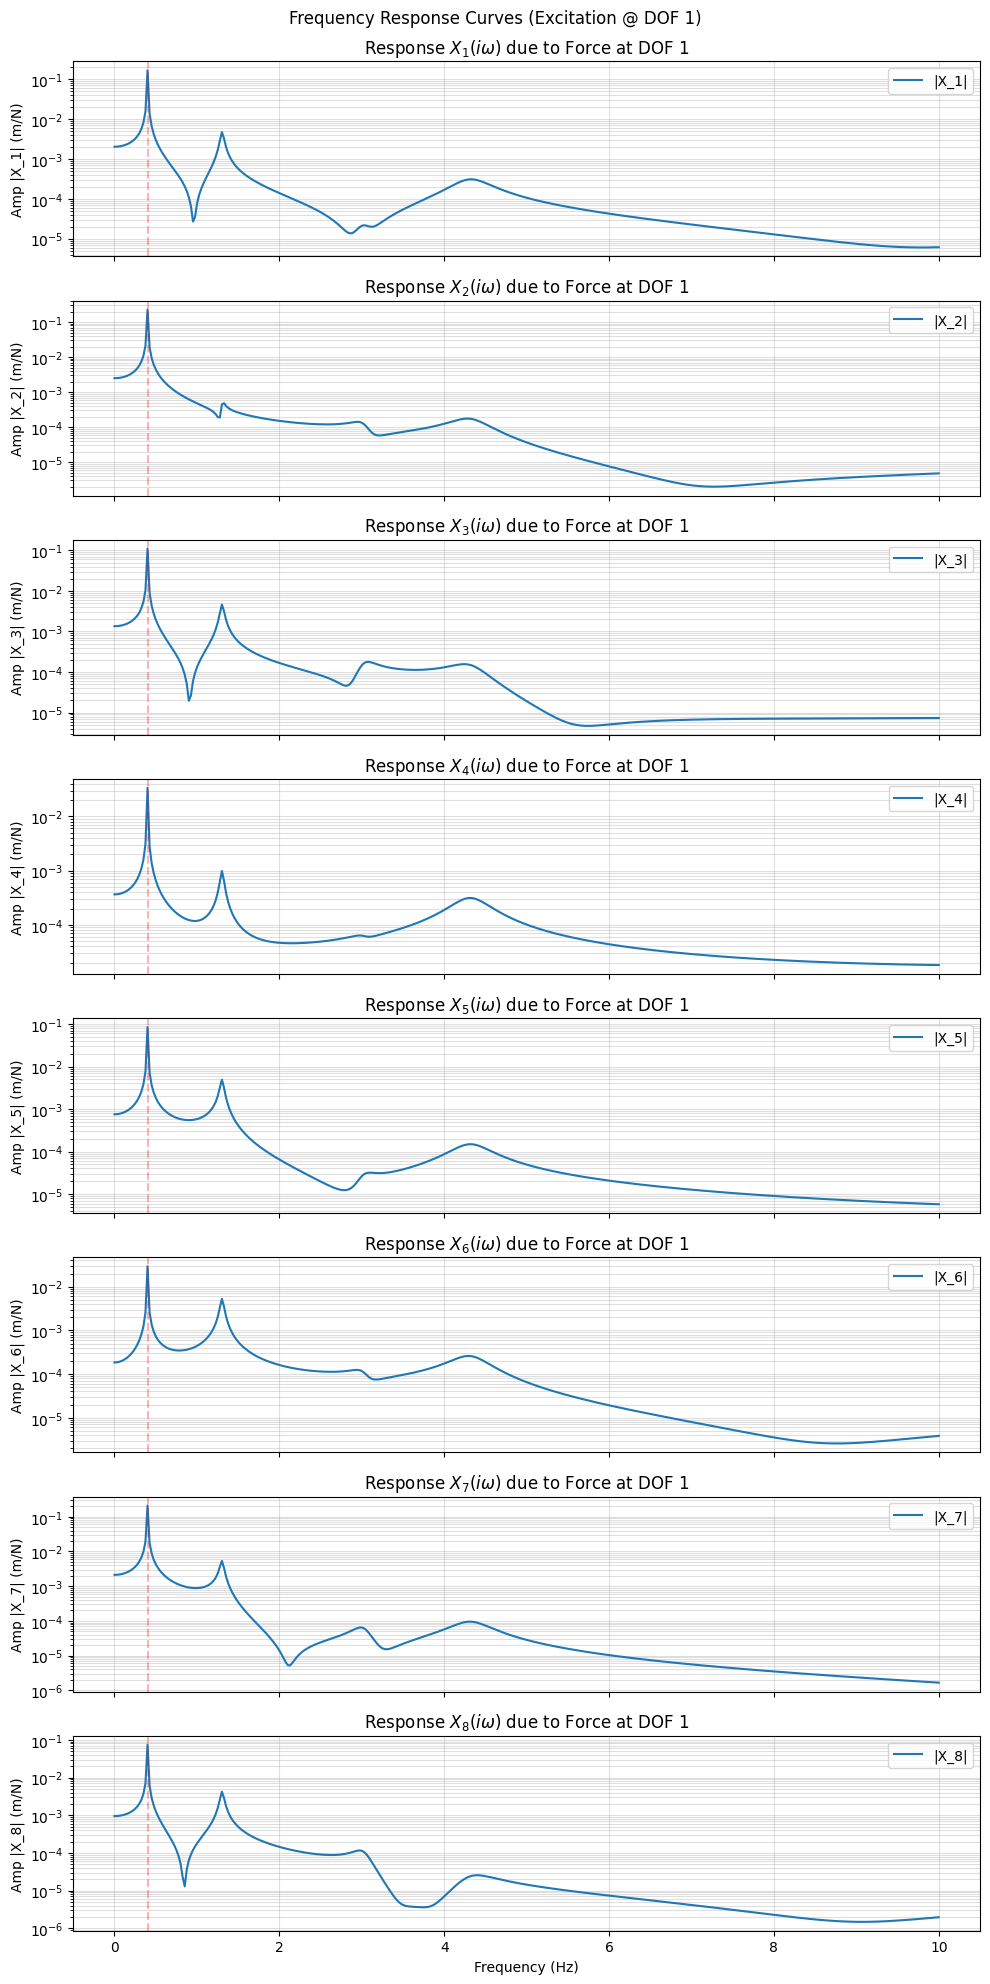

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, eig

# ==========================================
#               User Configuration
# ==========================================

# 1. File Paths
STIFFNESS_FILE = 'stiffness_matrix.xlsx'
MASS_FILE = 'mass_matrix.xlsx'
DAMPING_FILE = 'damping_matrix.xlsx'

# 2. Analysis Settings
FREQ_START = 0.0   # Hz
FREQ_END   = 10.0  # Hz
FREQ_POINTS = 400  # Number of points

# 3. Excitation Setting for Automatic Plots
# Which DOF is the force applied to for the X1, X2... plots?
AUTO_PLOT_FORCE_DOF = 1  # e.g., Force at DOF 1

# ==========================================
#             Core Logic
# ==========================================

def load_or_generate_data():
    """Loads Excel data, or generates a synthetic N-DOF system if files missing."""
    try:
        K = pd.read_excel(STIFFNESS_FILE).values
        M = pd.read_excel(MASS_FILE).values
        C = pd.read_excel(DAMPING_FILE).values
        print("Matrix data loaded successfully.")
        return K, M, C
    except FileNotFoundError:
        print("Excel files not found. Generating synthetic 4-DOF system for demonstration...")
        # Synthetic Data Generation (4-DOF Chain)
        n = 4
        M = np.eye(n) * 1.0
        K = np.zeros((n, n))
        k_val = 1000.0
        for i in range(n):
            K[i, i] = 2 * k_val
            if i > 0:
                K[i, i-1] = -k_val
                K[i-1, i] = -k_val
        # Rayleigh Damping
        C = 0.5 * M + 0.001 * K
        return K, M, C

def analyze_system():
    # 1. Load Data
    K, M, C = load_or_generate_data()
    dof = K.shape[0]

    # 2. Prepare Frequency Range
    f_range = np.linspace(FREQ_START, FREQ_END, FREQ_POINTS)
    w_range = 2 * np.pi * f_range
    
    # 3. Calculate Responses (X1, X2...) for the specified Force Input
    # We solve (K - w^2 M + i w C) * X = F
    force_idx = AUTO_PLOT_FORCE_DOF - 1
    F_vec = np.zeros(dof)
    F_vec[force_idx] = 1.0  # Unit Force
    
    # Store response magnitudes: Shape (DOF, Freq_Points)
    responses_mag = np.zeros((dof, len(f_range)))

    print(f"Calculating Frequency Response for Force at DOF {AUTO_PLOT_FORCE_DOF}...")
    
    for i, w in enumerate(w_range):
        Z = K - (w**2)*M + 1j*w*C
        # Solve Z * X = F for X
        X_vec = np.linalg.solve(Z, F_vec)
        responses_mag[:, i] = np.abs(X_vec)

    # 4. Automatic Plotting (Separated Subplots)
    # Dynamically adjust figure size based on DOF count
    fig, axes = plt.subplots(dof, 1, figsize=(10, 2.5 * dof), sharex=True)
    
    # Handle the case if dof=1 (axes is not a list)
    if dof == 1: 
        axes = [axes]

    for i in range(dof):
        ax = axes[i]
        # Plot Magnitude
        ax.semilogy(f_range, responses_mag[i, :], label=f'|X_{i+1}|', color='tab:blue')
        
        # Styling
        ax.set_ylabel(f'Amp |X_{i+1}| (m/N)')
        ax.set_title(f'Response $X_{{{i+1}}}(i\omega)$ due to Force at DOF {AUTO_PLOT_FORCE_DOF}')
        ax.grid(True, which="both", alpha=0.4)
        ax.legend(loc='upper right')
        
        # Optional: Mark Peak
        peak_idx = np.argmax(responses_mag[i, :])
        peak_freq = f_range[peak_idx]
        ax.axvline(peak_freq, color='r', linestyle='--', alpha=0.3)

    axes[-1].set_xlabel("Frequency (Hz)")
    plt.suptitle(f"Frequency Response Curves (Excitation @ DOF {AUTO_PLOT_FORCE_DOF})", y=0.99)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_system()